# Object detection on old maps


Goal is to detect buildings, both inhabited and un-inhabited from old maps and produce a GIS-layers of existing buildings for separate time-periods.

Further goal is then to analyze how the buildings have survived through the years.


The project was originally created in TensorFlow and Keras in 2023, now ported to pytorch-platform.

## Create the dataset

In [118]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

# Transformations
from torchvision.tv_tensors import BoundingBoxes
import torchvision.transforms.v2 as T

Create the Dataset-class, simple transformation and Dataloader-helper-function

In [119]:
class ObjectDetectionDataset(Dataset):
    def __init__(self, csv_file, transform=None):
        self.base_path = "data/images_train/" #
        self.annotations = pd.read_csv(csv_file)
        self.transform = transform

        # Group annotations by image as there are 0-n boxes per image
        self.image_groups = self.annotations.groupby("filename")

        # Unique image paths
        self.image_paths = list(self.image_groups.groups.keys())

    def __len__(self): # Returns the length of the IMAGES in dataset, not boxes
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path =  self.image_paths[idx]
        rows = self.image_groups.get_group(image_path) # Get all bboxes for image

        # Load image
        image = Image.open(self.base_path + image_path).convert("RGB")

        # Create lists to store the boxes and their labels
        boxes = []
        labels = []

        for _, row in rows.iterrows():
            boxes.append([
                row["xmin"],
                row["ymin"],
                row["xmax"],
                row["ymax"]
            ])
            labels.append(row["class_num"])

        # Operate based on if boxes on image:
        if len(boxes)==0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0, ), dtype=torch.int64)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.int64)

        # Create target:
        target = {"boxes": boxes, "labels": labels}

        # Convert to BoundingBox format to use the box-aware transforms.v2 -library
        target["boxes"] = BoundingBoxes(target["boxes"],
                                        format = "XYXY",
                                        canvas_size=image.size[::1]
                                        )

        if self.transform:
            image, target = self.transform(image, target)

        return image, target

In [120]:

# OLD-transforms
# Simple transformation, i.e. converting to tensor. 
# transform = transforms.Compose([
#     transforms.ToTensor(),  # Converts to [0,1] and CHW
#     # TODO: Placeholder for image augmentation; Note that only non-position-changing (brightness, colors etc) can be used easily
# ])

In [121]:
# Trasforms for training; NOTE: ToImage + ToDtype replaces ToTensor
train_transforms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.02),
    T.RandomAutocontrast(p=0.5)
])

# validation transforms; this only converts images to tensor, no augmentations
val_transforms = T.Compose([
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
])

In [122]:
dataset = ObjectDetectionDataset(
    csv_file="data/train_256px_annotations_extended_cleaned_2026.csv",
    transform=train_transforms
)

def collate_fn(batch):
    return tuple(zip(*batch))

dataloader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=collate_fn
)

### Test the dataloader


- Test shape of the outputs
- Test augmentations

In [123]:
# Shape of the outputs
temp_images, temp_targets = next(iter(dataloader))

# Print some example data
print(temp_images[0].shape) # RGB image; 3 x 256 x 256
print(temp_targets[0]['boxes']) # boxes; coords and some metadata
print(temp_targets[0]['labels']) # which classes boxes are

torch.Size([3, 256, 256])
BoundingBoxes([[ 38., 144.,  49., 157.],
               [ 32., 139.,  43., 149.],
               [ 58., 119.,  69., 130.],
               [ 42., 108.,  54., 120.],
               [243., 156., 255., 168.],
               [ 63., 105.,  75., 116.],
               [ 58., 101.,  68., 111.],
               [ 47., 132.,  58., 147.],
               [ 36., 130.,  47., 140.],
               [ 52., 133.,  65., 146.],
               [ 46.,  60.,  59.,  72.]], format=BoundingBoxFormat.XYXY, canvas_size=(256, 256), clamping_mode=soft)
tensor([1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1])


In [124]:
# Helper funcs to plot augmented results

import matplotlib.pyplot as plt
import matplotlib.patches as patches


def draw_boxes(ax, boxes, labels=None, color="lime"):
    """
    ax     : matplotlib axis
    boxes  : Tensor[N, 4] in XYXY format
    labels : optional Tensor[N]
    """
    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box.tolist()
        w, h = x2 - x1, y2 - y1

        rect = patches.Rectangle(
            (x1, y1),
            w,
            h,
            linewidth=2,
            edgecolor=color,
            facecolor="none"
        )
        ax.add_patch(rect)

        if labels is not None:
            ax.text(
                x1,
                y1 - 3,
                str(int(labels[i])),
                color=color,
                fontsize=9,
                bbox=dict(facecolor="black", alpha=0.5, pad=1)
            )


def visualize_batch(dataloader, max_images=4):
    images, targets = next(iter(dataloader))

    batch_size = min(len(images), max_images)
    fig, axes = plt.subplots(1, batch_size, figsize=(5 * batch_size, 5))

    if batch_size == 1:
        axes = [axes]

    for i in range(batch_size):
        image = images[i]
        target = targets[i]

        # CHW → HWC
        img_np = image.permute(1, 2, 0).cpu().numpy()

        axes[i].imshow(img_np)
        axes[i].axis("off")

        boxes = target["boxes"]
        labels = target["labels"]

        # BoundingBoxes → Tensor (important)
        if hasattr(boxes, "to_tensor"):
            boxes = boxes.to_tensor()

        if len(boxes) > 0:
            draw_boxes(axes[i], boxes, labels)

    plt.tight_layout()
    plt.show()


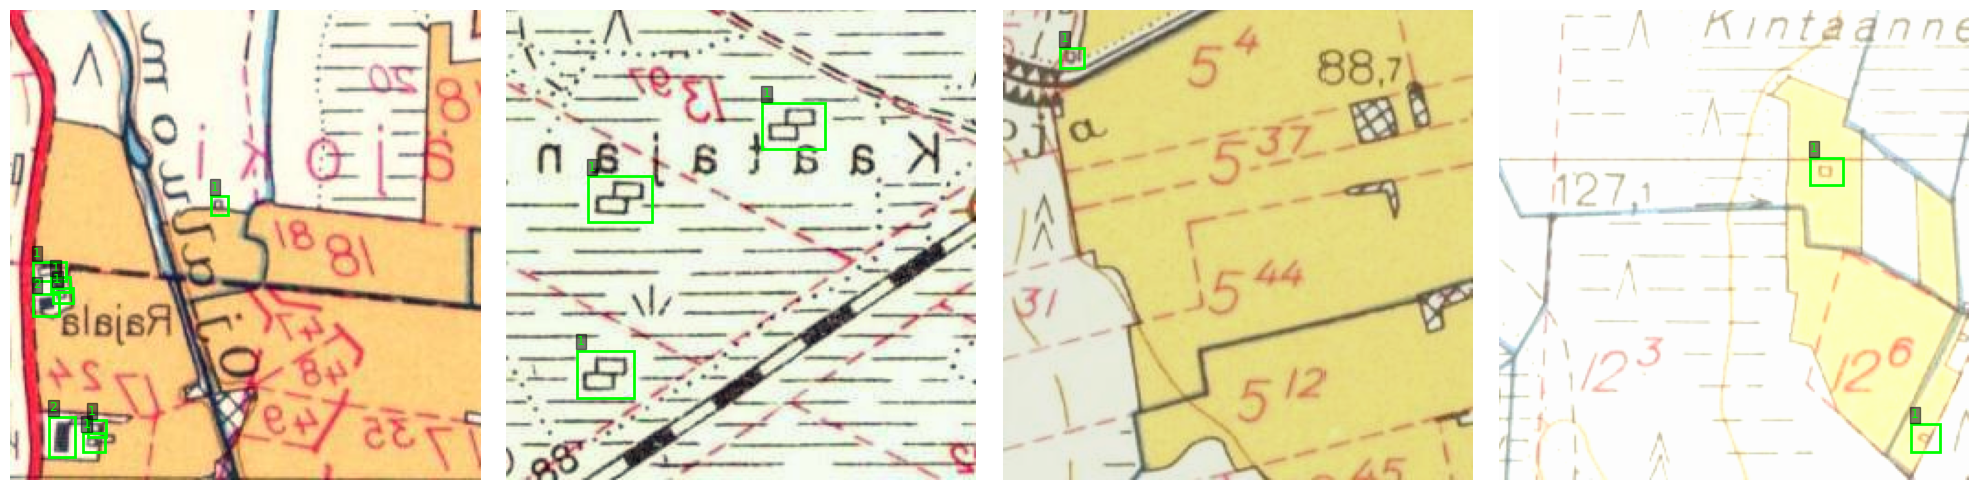

In [125]:
visualize_batch(dataloader, max_images=4)

## Model

In [126]:
# import torchvision.models.detection.fasterrcnn_resnet50_fpn

import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.rpn import AnchorGenerator

In [127]:

model = torchvision.models.detection.fasterrcnn_resnet50_fpn(
    # pretrained=True, # Deprecated param
    weights='FasterRCNN_ResNet50_FPN_Weights.DEFAULT',
    min_size=256,
    max_size=256
)


In [128]:
# Inspect the internal stucture of the model and its params at high level
def print_module_tree(module, prefix=""):
    for name, child in module.named_children():
        print(prefix + name, "→", type(child))
        print_module_tree(child, prefix + "  ")

print_module_tree(model)

transform → <class 'torchvision.models.detection.transform.GeneralizedRCNNTransform'>
backbone → <class 'torchvision.models.detection.backbone_utils.BackboneWithFPN'>
  body → <class 'torchvision.models._utils.IntermediateLayerGetter'>
    conv1 → <class 'torch.nn.modules.conv.Conv2d'>
    bn1 → <class 'torchvision.ops.misc.FrozenBatchNorm2d'>
    relu → <class 'torch.nn.modules.activation.ReLU'>
    maxpool → <class 'torch.nn.modules.pooling.MaxPool2d'>
    layer1 → <class 'torch.nn.modules.container.Sequential'>
      0 → <class 'torchvision.models.resnet.Bottleneck'>
        conv1 → <class 'torch.nn.modules.conv.Conv2d'>
        bn1 → <class 'torchvision.ops.misc.FrozenBatchNorm2d'>
        conv2 → <class 'torch.nn.modules.conv.Conv2d'>
        bn2 → <class 'torchvision.ops.misc.FrozenBatchNorm2d'>
        conv3 → <class 'torch.nn.modules.conv.Conv2d'>
        bn3 → <class 'torchvision.ops.misc.FrozenBatchNorm2d'>
        relu → <class 'torch.nn.modules.activation.ReLU'>
        dow

In [129]:
# Detailed view of model params and WHERE they are.

# Looping over all the params of the model: 
# NOTE: Tested and Level 4 is irrelavant; they are methods for converting the inputs from float, nominators etc.
# Use only the level 3
model_param_list = []

for attr_l1 in dir(model):
    for attr_l2 in dir(getattr(model, attr_l1)):
        attr_l3 = dir(getattr(getattr(model, attr_l1), attr_l2))
        model_param_list.append(pd.DataFrame({'L1': attr_l1, 'L2': attr_l2, 'L3': attr_l3}))


# for attr_l1 in dir(model):
#     for attr_l2 in dir(getattr(model, attr_l1)):
#         for attr_l3 in dir(getattr(getattr(model, attr_l1), attr_l2)):
#             print(attr_l1, attr_l2, attr_l3)
#             try:
#                 attr_l4 = dir(getattr(getattr(getattr(model, attr_l1), attr_l2), attr_l3))
#             except:
#                 attr_l4 = ["no_attributes"]
#             model_param_list.append(pd.DataFrame({'L1': attr_l1, 'L2': attr_l2, 'L3': attr_l3, 'L4': attr_l4}))

# Combine and filter out internal params starting with underscore
model_param_list_df = pd.concat(model_param_list, ignore_index = True)
model_param_list_df2 = model_param_list_df[(~model_param_list_df.L1.str.startswith("_"))&(~model_param_list_df.L2.str.startswith("_"))&(~model_param_list_df.L3.str.startswith("_"))].copy()

# Create one additional column for easy string-searching
model_param_list_df2['L123'] = model_param_list_df2['L1'] + '.' + model_param_list_df2['L2'] + '.' + model_param_list_df2['L3']

In [130]:
# NOTE:
# Many similar params exists at level L3 between L1-modules roi_heads and rpn. rpn is the first step in the journey,
# and therefore needs to be tuned first
# RPN = "Where any of the objects are" (Coarse regions of potential candidates for deeper inspection)
# ROI_Heads: "Where exactly and what are the objects (classification + refining box coords)"

model_param_list_df2[model_param_list_df2.L123.str.contains("batch_size_per_image")]



,L1,L2,L3,L123
143098,roi_heads,fg_bg_sampler,batch_size_per_image,roi_heads.fg_bg_sampler.batch_size_per_image
148161,rpn,fg_bg_sampler,batch_size_per_image,rpn.fg_bg_sampler.batch_size_per_image


In [131]:
# TODO: Search all the relevant runable params and get their names and locations + default-values

Customize the number of classes and create a new box-predictor-head with updated number of classes

In [132]:
num_classes = 3  # background + 2 object classes
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

Parameter tuning - need to customize for the small objects, as they are only covering 1% of the image-area.

In [133]:
anchor_generator = AnchorGenerator(
    sizes=((8, 16, 32),),  # MUCH smaller than defaults; note that these are taken from EDA
    aspect_ratios=((0.5, 1.0, 1.5, 2.0),)
)

model.rpn.anchor_generator = anchor_generator

In [134]:
# Treshold for the detection; these are IoU-ratios (Intersection over Union, i.e. how much of the areas overlap between model-proposed vs. ground-truth training-labels)
model.rpn.proposal_matcher.high_threshold # defaults to 0.7; higher than this are consider good matches
model.rpn.proposal_matcher.low_threshold # defaults to 0.3; LOWER than this are consider background, i.e. 
# model.rpn.proposal_matcher.high_threshold = 0.6 # Lowering for not being too strict, allowing more proposals for positive matches

0.3

In [135]:
# How many samples per image? If objects are relatively rare (i.e. most is background), this should be incresed
# model.rpn.batch_size_per_image # defaults to 
# model.rpn.batch_size_per_image = 256

In [ ]:
# Region-Of-Interest (ROI): Finetuning the anchored area:
# Setting to lower increases number of detections --> lift later to reduce false positives
model.roi_heads.score_thresh # defaults to 
# model.roi_heads.score_thresh = 0.3

# Non-maximum-supression (nms): How much overlap is tolerated? Lower means clustered objects are outputted as single
model.roi_heads.nms_thresh # def 0.5
# model.roi_heads.nms_thresh = 0.5

0.5

In [ ]:
# How many objects to detect from image?
model.roi_heads.detections_per_img # defaults to 100
# model.roi_heads.detections_per_img = 100

100